# Libraries

In [12]:
from src.DGN.imports import *
from src.DGN.config import *
from src.DGN.model import Tox21GNN
from src.DGN.dataset import Dataset_tox21

In [4]:
def set_seed(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 2. Numpy
    np.random.seed(seed)
    
    # 3. PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
set_seed(RANDOM_SEED)

In [5]:
warnings.filterwarnings("ignore", message=".*torch-scatter.*")

# Dataset - Tox21
---
We have appended other 2 features linked to the toxicity dataset: **Molecular Weight (MW) and LogP(lipofily)**

***Note: we have considered also another feature called Global Toxicity 1/0 ***



In [6]:
tox21_df=pd.read_csv(DATASET_PATH)
print(f"Dataset caricato! Dimensioni: {tox21_df.shape}")



target_cols = [c for c in tox21_df.columns if c.startswith(('NR-', 'SR-'))]

#extraction of smiles,labels and global features
smiles=tox21_df["smiles"].values
global_features=tox21_df[["MW","LogP"]].values.astype(float)
labels=tox21_df[target_cols].values.astype(float)

print(f"- {len(smiles)} stringhe SMILES")
print(f"- Matrice Labels shape: {labels.shape}")
print(f"- Matrice Global Features shape: {global_features.shape}")
#tox21_df.head()




Dataset caricato! Dimensioni: (7823, 15)
- 7823 stringhe SMILES
- Matrice Labels shape: (7823, 12)
- Matrice Global Features shape: (7823, 2)


# Dataset class
---
## Extraction of features 
In our case we should manipulate molecule using a graph in which each node is an atom and each edge is a bond with another it.  
for each node we identify the following features otherwise it will be impossible to learn its chemical properties and structure:

- **Atom Type** (C, N, O, S, F, Cl, Br, I, P...) using One-Hot Encoding
- **Degree** (es. 1, 2, 3, 4).
- **Hybridization** (orbital geometry  ($sp, sp^2, sp^3$))
- **Aromatic** boolean values if atom belongs to the aromatic chain or not
- **Number of Hydrogens** (how many Hydrogens are attached )
- **Chirality** (if atom is chiral center R or S)
- **isDonor**  ( 1 or 0 Donates  electrons)
- **isAcceptor** (1 or 0 accepts electrons)
- **Formal Charge** (es. -1, 0, +1)




# Dataloader 

In [ ]:

full_dataset= Dataset_tox21(smiles=smiles,labels=labels,global_parameters=global_features,permitted_atoms=TYPE_ATOMS,hybrization_type=HYBRIDIZATION_TYPE,degree_atoms=ATOM_DEGREE,number_hydrogens=NUMBER_HYDROGENS,permitted_bonds=PERMITTED_BONDS,stereo_list=STEREO_LIST)

dataset_size=len(full_dataset)
val_size = int(dataset_size * VAL_PERCENTAGE) 
test_size= int(dataset_size* TEST_PERCENTAGE)
train_size = dataset_size - val_size - test_size

print(f"Totale Molecole: {dataset_size}")
print(f"Training Set: {train_size}")
print(f"Test Set: {test_size}")

generator= torch.Generator().manual_seed(RANDOM_SEED)

#division randomically 
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, 
    [train_size, val_size, test_size], 
    generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=PIN_MEMORY)
print("train loader ok")
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=PIN_MEMORY)
print("val loader ok")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=PIN_MEMORY)
print("test loader ok")
for batch in train_loader:
    print(f"Batch scaricato: {batch}")
    print(f" - Batch x shape: {batch.x.shape}")     # [Num_Atomi_Totali_nel_batch, Features]
    print(f" - Batch y shape: {batch.y.shape}")     # [64, 12] -> Ecco le label per 64 molecole
    print(f" - Batch edge_index: {batch.edge_index.shape}")
    break 

ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

# GNN Model
--- 

It is characterized by two models:
1) **GINMLP** 
2) **GNN**

In [ ]:
   
model=Tox21GNN(
    num_node_features=NODE_FEATURES,
    hidden_channels=HIDDEN_CHANNELS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT)

model = model.to(DEVICE)

#print(f"Using device: {DEVICE}")    
#print(model)        

Usando device: cuda


# Train

# Compute weights to give a weighted loss wrt tO 12 classes of toxicities

In [9]:
def compute_class_weights(loader):
    print("Calcolo dei pesi per il bilanciamento classi (pos_weight)...")
    all_labels = []
    
   
    for batch in loader:
        all_labels.append(batch.y)
    
    
    all_labels = torch.cat(all_labels, dim=0).numpy()
    
    weights = []
    for i in range(12): # Per (colonna)
        col = all_labels[:, i]
    
        valid_indices = ~np.isnan(col)
        valid_labels = col[valid_indices]
        
        n_pos = np.sum(valid_labels == 1)
        n_neg = np.sum(valid_labels == 0)
        
        if n_pos > 0:
            weight = n_neg / n_pos
        else:
            weight = 1.0 # Fallback se non ci sono positivi (raro)
            
        weights.append(weight)
        
    return torch.tensor(weights, dtype=torch.float)


class_weights = compute_class_weights(train_loader)
print(f"Pesi calcolati: {class_weights}")


class_weights = class_weights.to(DEVICE)

Calcolo dei pesi per il bilanciamento classi (pos_weight)...
Pesi calcolati: tensor([22.0045, 27.6970,  7.5139, 18.8204,  6.7639, 17.9650, 29.9384,  4.9414,
        24.3897, 16.0682,  5.4214, 14.7774])


# Configuration

In [10]:
def create_lr_scheduler(optimizer, num_train_steps, warmup_steps):
    """Creates a learning rate scheduler with a linear warmup and cosine decay."""
    
    # Scheduler for the linear warmup phase
    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_steps
    )
    
    # Scheduler for the cosine decay phase
    decay_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=(num_train_steps - warmup_steps)
    )
    
    # Chain them together
    lr_scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, decay_scheduler],
        milestones=[warmup_steps]
    )
    return lr_scheduler

# Configuration optimizer,scheduler e criterion

In [11]:
steps_per_epoch = len(train_loader)
total_steps = EPOCHS * steps_per_epoch
warmup_steps = int(total_steps * 0.20) # 10% del tempo speso in warmup

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY) # initial lr=0.001 and weight_decay=5e-4
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=class_weights, reduction='none')
scheduler = create_lr_scheduler(optimizer, total_steps, warmup_steps)

# Validation step

In [ ]:
from src.DGN.train import train_one_epoch
from src.DGN.evaluate import run_validation_epoch
from src.DGN.evaluate import compute_val_roc_auc

print("Start Training")
best_val_auc = 0.0
save_path = './checkpoints/best_tox21_model.pth'

for epoch in range(EPOCHS):
    train_loss=train_one_epoch(model,train_loader,scheduler,criterion,optimizer,True)
    val_loss = run_validation_epoch(model,val_loader,criterion)
    
    current_val_auc = compute_val_roc_auc(model, val_loader,True)
    
    print(f"Epoch {epoch + 1}/{EPOCHS} | Training Loss: {train_loss:.6f} | Validation Loss: {val_loss:.6f}")
    
    if current_val_auc > best_val_auc:
        best_val_auc = current_val_auc
        torch.save(model.state_dict(), save_path)
        print(f"Nuovo Record! Salvato at epoch: {epoch+1}")

   

# Hyperparameter Tuning
---
 

In [ ]:
def objective(trial):
    # 1. Suggerimento Iperparametri (Optuna sceglie qui i valori per questo tentativo)
    param = {
        'hidden_channels': trial.suggest_categorical('hidden_channels', [32, 64, 128, 256]),
        'lr': trial.suggest_float('lr', 1e-5, 1e-2, log=True),  # Cerca tra 0.00001 e 0.01
        'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128]),
        'dropout': trial.suggest_float('dropout', 0.2, 0.6),
        'epochs': EPOCHS # Teniamo le epoche fisse per confronto equo
    }

    # 2. Setup DataLoaders (Dinamici in base al batch_size scelto)
    train_loader_tune = DataLoader(train_dataset, batch_size=param['batch_size'], shuffle=True,pin_memory=PIN_MEMORY )
    val_loader_tune = DataLoader(val_dataset, batch_size=param['batch_size'], shuffle=False,pin_memory=PIN_MEMORY)
    
    # 3. Creazione Modello (Dinamico)
    model = Tox21GNN(
        num_node_features=NODE_FEATURES, 
        hidden_channels=param['hidden_channels'],
        num_classes=NUM_CLASSES,
        # Se hai aggiunto dropout all'init, passalo qui: dropout=param['dropout']
        dropout=param['dropout']
    ).to(DEVICE)

    # 4. Ottimizzatore e Loss
    optimizer = torch.optim.Adam(model.parameters(), lr=param['lr'], weight_decay=param['weight_decay'])
    # Ricalcoliamo lo scheduler in base al nuovo batch size (steps cambiano!)
    total_steps = param['epochs'] * len(train_loader_tune)
    scheduler = create_lr_scheduler(optimizer, total_steps, warmup_steps=int(total_steps*0.2))
    
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=class_weights, reduction='none')
    val_roc_auc=0
    for epoch in range(param['epochs']):
        train_loss=train_one_epoch(model,train_loader=train_loader_tune,scheduler=scheduler,criterion=criterion,optimizer=optimizer,isprogress=False)
        #val_loss = run_validation_epoch(model,val_loader=val_loader_tune,criterion=criterion)
        
        #feedback ad optuna per riportare l'andamento dell'addestramento
        val_roc_auc=compute_val_roc_auc(model,val_loader_tune,False)
        trial.report(val_roc_auc, epoch)
        
        # se il trial è peggiore degli altri lo uccide
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        
    return val_roc_auc
    
print("Inizio Hyperparameter Tuning con Optuna...")

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)       
study = optuna.create_study(direction='maximize',sampler=sampler, pruner=optuna.pruners.MedianPruner())

study.optimize(objective, n_trials=60)        

print("\n--- TUNING COMPLETATO ---")
print("Migliori parametri trovati:")
print(study.best_params)
print(f"Miglior media ROC-AUC trovata: {study.best_value}")

fig1 = plot_optimization_history(study)
fig1.show()

# Grafico 2: Importanza parametri (Ti dirà: "Il Learning Rate conta per il 60%, il Dropout non conta nulla")
fig2 = plot_param_importances(study)
fig2.show()

In [ ]:
best_param=study.best_params
print(best_param)

# Test


In [18]:
def get_predictions(model,device):
    model.eval()
    all_probs = []
    all_targets = []
    
    print("Generazione previsioni sul Test Set...")
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Testing"):
            batch = batch.to(device)
            
            # 1. Forward Pass
            logits = model(batch.x, batch.edge_index,batch.edge_attr, batch.batch, batch.global_feat)
            
            # 2. Applicazione Sigmoide (Logits -> Probabilità 0-1)
            probs = torch.sigmoid(logits)
            
            # 3. Spostiamo su CPU e salviamo
            all_probs.append(probs.cpu())
            all_targets.append(batch.y.cpu())
            
    # Concateniamo tutto in due grandi matrici
    y_probs = torch.cat(all_probs, dim=0).numpy()
    y_true = torch.cat(all_targets, dim=0).numpy()
    
    return y_probs, y_true

#LOAD BEST MODEL
model.load_state_dict(torch.load(save_path))

y_probs, y_true = get_predictions(model,DEVICE)
print(f"Shape Previsioni: {y_probs.shape}")
print(y_probs)

Generazione previsioni sul Test Set...


Testing:   0%|          | 0/19 [00:00<?, ?it/s]

Shape Previsioni: (1173, 12)
[[0.15516105 0.05257079 0.05948867 ... 0.26251513 0.03325024 0.06735241]
 [0.2754372  0.21214578 0.10046069 ... 0.44227386 0.7648742  0.22690676]
 [0.25533018 0.09122354 0.7592025  ... 0.4259057  0.49411336 0.31577533]
 ...
 [0.33162507 0.28513598 0.16887102 ... 0.22004753 0.03269266 0.2277869 ]
 [0.16613276 0.09880774 0.08746753 ... 0.39164382 0.08514661 0.14216004]
 [0.09828819 0.07164646 0.60130847 ... 0.35679528 0.39775226 0.13628475]]


# Results

In [22]:
# Nomi dei 12 target di Tox21 (nell'ordine corretto del dataset)
task_names = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 
    'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'
]

roc_auc_scores = []
print("\n" + "="*50)
print(f"{'TASK NAME':<20} | {'ROC-AUC':<10} | {'Etichette Valide'}")
print("="*50)
list_confusion_matrix=[]
for i, name in enumerate(task_names):
    # Estraiamo la colonna i-esima
    col_true = y_true[:, i]
    col_pred = y_probs[:, i]
    
    # MASCHERA PER I NaN
    # Prendiamo solo gli indici dove abbiamo una etichetta reale
    mask = ~np.isnan(col_true)
    valid_true = col_true[mask]
    valid_pred = col_pred[mask]
    
    # Controllo di sicurezza: Servono almeno una classe positiva e una negativa
    # altrimenti ROC-AUC crasha
    if len(np.unique(valid_true)) < 2:
        print(f"{name:<20} | {'N/A':<10} | {len(valid_true)} (Solo una classe)")
        continue
        
    # Calcolo Score
    
    score = roc_auc_score(valid_true, valid_pred)
    roc_auc_scores.append(score)
    
    #Compute confusion matrix
    valid_pred = (valid_pred > 0.5).astype(int)
    valid_true = valid_true.astype(int)
    
    cm =confusion_matrix(valid_true, valid_pred, labels=[0, 1])
    list_confusion_matrix.append(cm)
    
    print(f"{name:<20} | {score:.4f}     | {len(valid_true)}")

print("-" * 50)
print(f"MEDIA TOTALE ROC-AUC: {np.mean(roc_auc_scores):.4f}")
print("=" * 50)


TASK NAME            | ROC-AUC    | Etichette Valide
NR-AR                | 0.8800     | 1087
NR-AR-LBD            | 0.8938     | 1006
NR-AhR               | 0.8665     | 979
NR-Aromatase         | 0.8527     | 885
NR-ER                | 0.7135     | 927
NR-ER-LBD            | 0.8612     | 1041
NR-PPAR-gamma        | 0.8623     | 963
SR-ARE               | 0.8332     | 878
SR-ATAD5             | 0.8974     | 1058
SR-HSE               | 0.8810     | 976
SR-MMP               | 0.9189     | 875
SR-p53               | 0.8049     | 1013
--------------------------------------------------
MEDIA TOTALE ROC-AUC: 0.8555


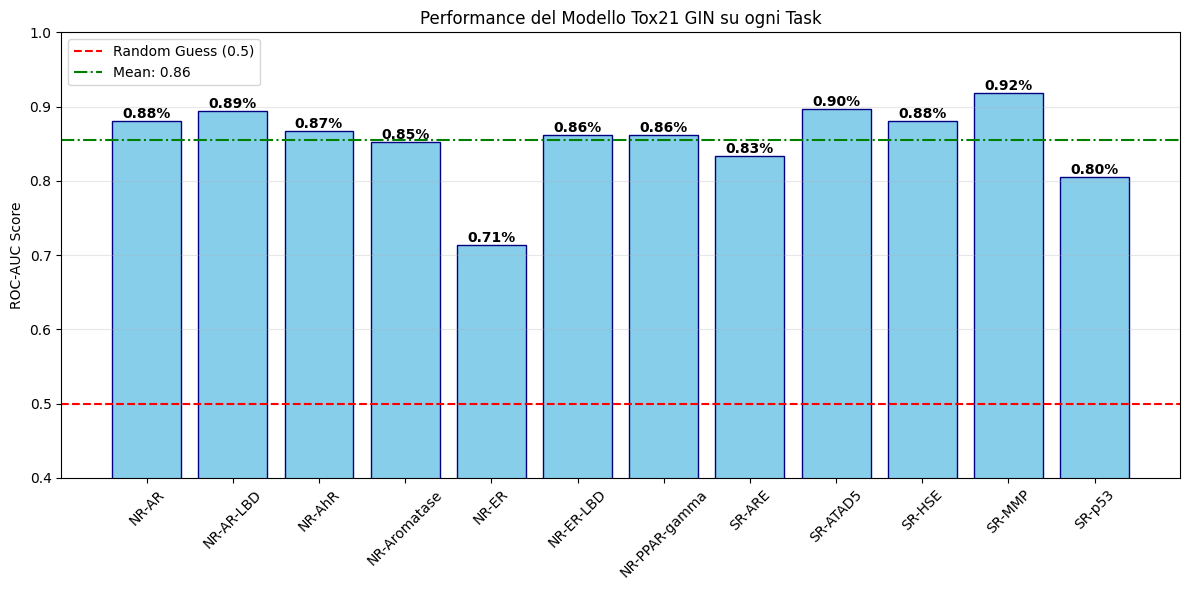

In [20]:
plt.figure(figsize=(12, 6))
plt.bar(task_names, roc_auc_scores, color='skyblue', edgecolor='navy')
plt.axhline(y=0.5, color='r', linestyle='--', label='Random Guess (0.5)')
plt.axhline(y=np.mean(roc_auc_scores), color='g', linestyle='-.', label=f'Mean: {np.mean(roc_auc_scores):.2f}')

plt.ylim(0.4, 1.0) # ROC-AUC va da 0.5 a 1.0 (sotto 0.5 il modello è rotto)
plt.ylabel('ROC-AUC Score')
plt.title('Performance del Modello Tox21 GIN su ogni Task')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
for i,v in enumerate(roc_auc_scores):
    plt.text(i, v , f'{v:0.2f}%', color='black', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# ConfusionMatrix 

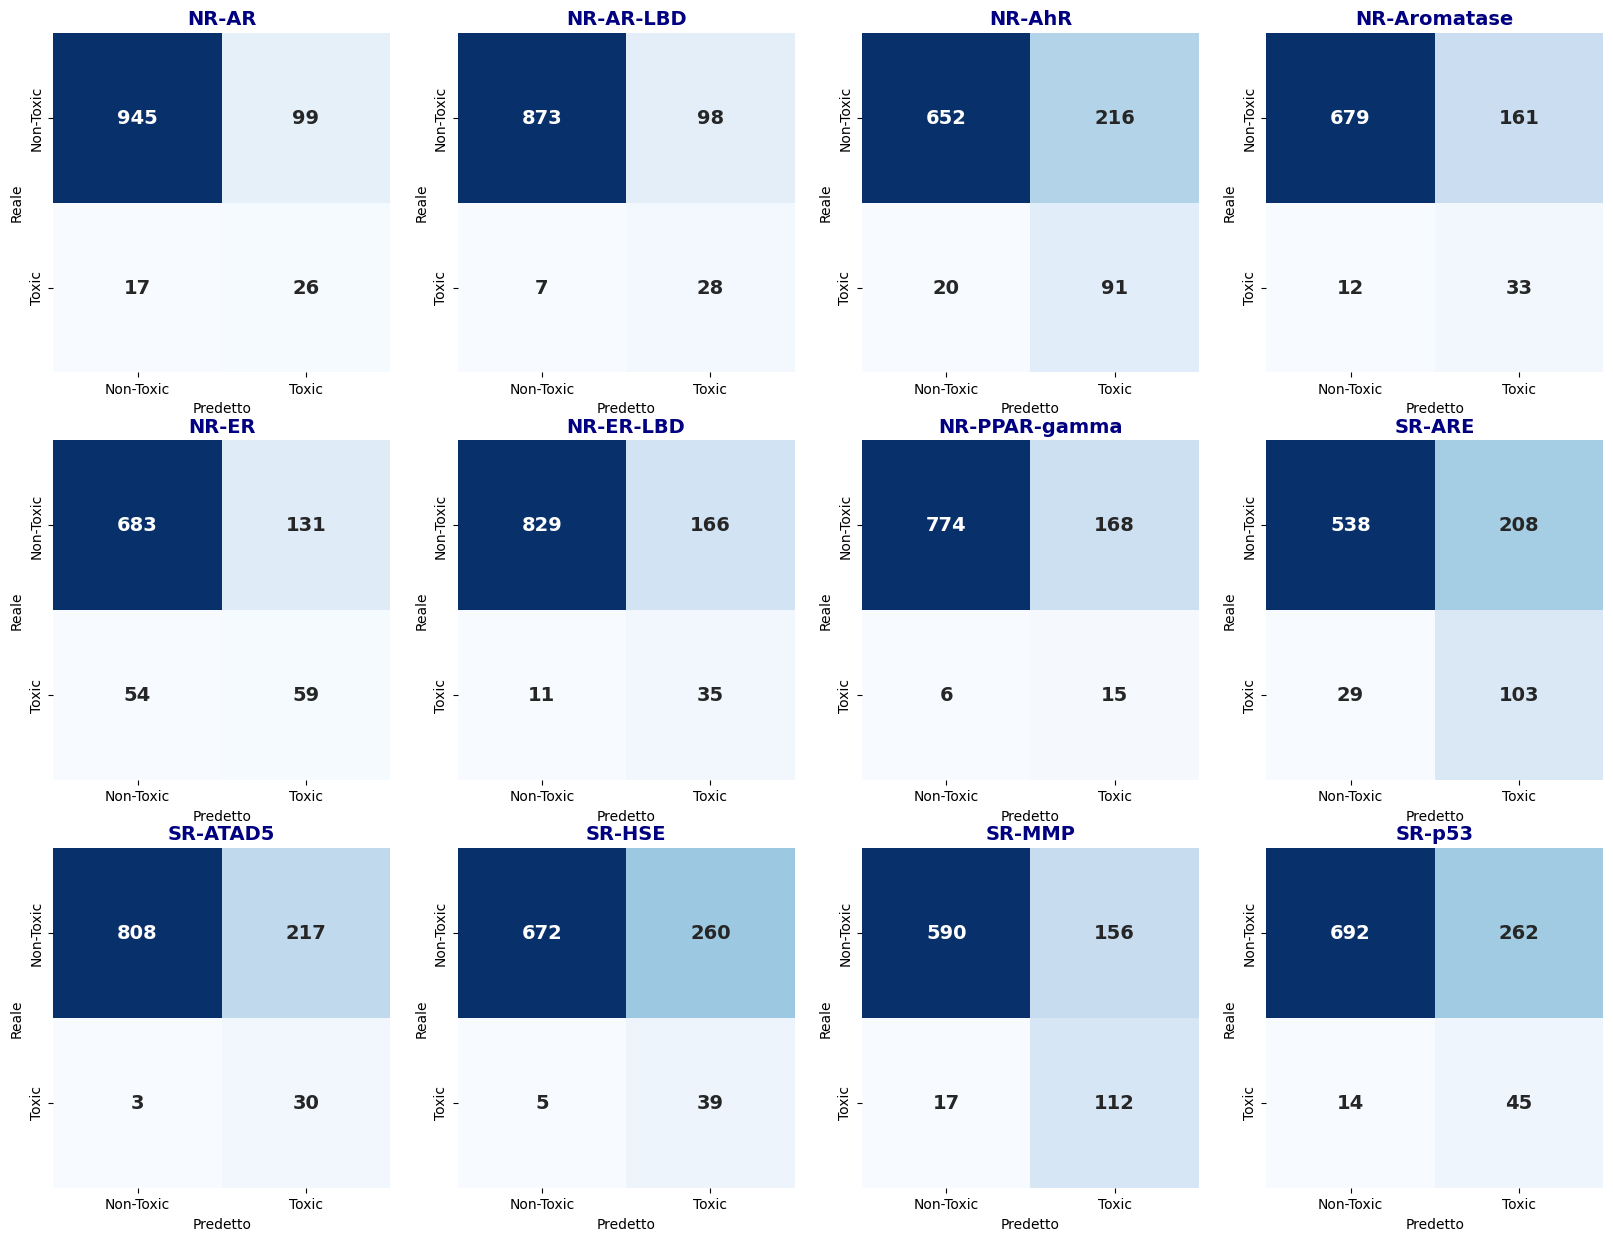

In [19]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()
for i, ax in enumerate(axes):
    task_name=task_names[i]
    
    sns.heatmap(list_confusion_matrix[i], annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                annot_kws={"size": 14, "weight": "bold"})
    
    # Estetica
    ax.set_title(f"{task_name}", fontsize=14, fontweight='bold', color='navy')
    ax.set_xlabel('Predetto', fontsize=10)
    ax.set_ylabel('Reale', fontsize=10)
    ax.set_xticklabels(['Non-Toxic', 'Toxic'])
    ax.set_yticklabels(['Non-Toxic', 'Toxic'])